# Bitcoin Market Sentiment vs Hyperliquid Trader Performance Analysis

This notebook is the starting point for the assignment project. It loads the two datasets, inspects them, cleans timestamps, and prepares the analysis workflow for sentiment-based trader performance insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully.')

historical_path = 'data/historical_data.csv'
fear_greed_path = 'data/fear_greed_index.csv'

historical_df = pd.read_csv(historical_path)
fear_greed_df = pd.read_csv(fear_greed_path)

print('Historical shape:', historical_df.shape)
print('Fear & Greed shape:', fear_greed_df.shape)
print('\nHistorical columns:', list(historical_df.columns))
print('Fear & Greed columns:', list(fear_greed_df.columns))

historical_df.head()


Libraries imported successfully.
Historical shape: (5, 12)
Fear & Greed shape: (4, 4)

Historical columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Fee', 'Trade ID']
Fear & Greed columns: ['timestamp', 'value', 'classification', 'date']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Fee,Trade ID
0,A001,BTC,65000,0.20,13000,BUY,2024-01-10 09:30:00,0,Long,150.5,12.0,T001
1,A001,BTC,65500,0.15,9825,SELL,2024-01-11 10:45:00,1,Long,-25.0,8.5,T002
2,A002,ETH,3500,5.00,17500,BUY,2024-01-10 11:15:00,0,Long,80.0,6.0,T003
3,A002,ETH,3480,4.00,13920,SELL,2024-01-12 09:20:00,1,Long,45.0,5.5,T004
4,A003,BTC,67000,0.25,16750,BUY,2024-01-13 11:00:00,0,Long,210.0,15.0,T005


In [7]:
historical_df.info()
print('\n--- HISTORICAL MISSING VALUES ---')
print(historical_df.isnull().sum())
print('\n--- FEAR & GREED INFO ---')
fear_greed_df.info()
print('\n--- FEAR & GREED MISSING VALUES ---')
print(fear_greed_df.isnull().sum())

# Clean timestamps and create merge keys
historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], errors='coerce')
fear_greed_df['timestamp'] = pd.to_datetime(fear_greed_df['timestamp'], errors='coerce')

historical_df['trade_date'] = historical_df['Timestamp IST'].dt.normalize()
fear_greed_df['trade_date'] = fear_greed_df['timestamp'].dt.normalize()

print('\nHistorical duplicate trade IDs:', historical_df['Trade ID'].duplicated().sum())
print('Fear & Greed duplicate rows:', fear_greed_df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Account          5 non-null      str           
 1   Coin             5 non-null      str           
 2   Execution Price  5 non-null      int64         
 3   Size Tokens      5 non-null      float64       
 4   Size USD         5 non-null      int64         
 5   Side             5 non-null      str           
 6   Timestamp IST    5 non-null      datetime64[us]
 7   Start Position   5 non-null      int64         
 8   Direction        5 non-null      str           
 9   Closed PnL       5 non-null      float64       
 10  Fee              5 non-null      float64       
 11  Trade ID         5 non-null      str           
 12  trade_date       5 non-null      datetime64[us]
dtypes: datetime64[us](2), float64(3), int64(3), str(5)
memory usage: 652.0 bytes

--- HISTORICAL MISSING VALUES --

In [8]:
# Demonstrate merge types
left_merge = pd.merge(historical_df, fear_greed_df[['trade_date', 'value', 'classification']], on='trade_date', how='left')
right_merge = pd.merge(historical_df, fear_greed_df[['trade_date', 'value', 'classification']], on='trade_date', how='right')
inner_merge = pd.merge(historical_df, fear_greed_df[['trade_date', 'value', 'classification']], on='trade_date', how='inner')

print('Left merge shape:', left_merge.shape)
print('Right merge shape:', right_merge.shape)
print('Inner merge shape:', inner_merge.shape)
print('\nLeft merge sample:')
print(left_merge[['Trade ID', 'trade_date', 'classification', 'Closed PnL']].head(8))

# Why left join is appropriate here:
# It keeps all trade records and adds sentiment context where available.


Left merge shape: (5, 15)
Right merge shape: (5, 15)
Inner merge shape: (5, 15)

Left merge sample:
  Trade ID trade_date classification  Closed PnL
0     T001 2024-01-10   Extreme Fear       150.5
1     T002 2024-01-11        Neutral       -25.0
2     T003 2024-01-10   Extreme Fear        80.0
3     T004 2024-01-12          Greed        45.0
4     T005 2024-01-13  Extreme Greed       210.0


## Sentiment-Based Performance Metrics

This section calculates average PnL, total PnL, median PnL, and trade counts grouped by sentiment class to reveal how each market mood relates to trader profitability.

In [9]:
# Ensure the required date keys exist before merging
if 'trade_date' not in historical_df.columns:
    historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], errors='coerce')
    fear_greed_df['timestamp'] = pd.to_datetime(fear_greed_df['timestamp'], errors='coerce')
    historical_df['trade_date'] = historical_df['Timestamp IST'].dt.normalize()
    fear_greed_df['trade_date'] = fear_greed_df['timestamp'].dt.normalize()

merged = pd.merge(
    historical_df,
    fear_greed_df[['trade_date', 'value', 'classification']],
    on='trade_date',
    how='left'
)

sentiment_summary = (
    merged.groupby('classification', dropna=False)
          .agg(
              avg_pnl=('Closed PnL', 'mean'),
              median_pnl=('Closed PnL', 'median'),
              total_pnl=('Closed PnL', 'sum'),
              trade_count=('Trade ID', 'count')
          )
          .sort_values('total_pnl', ascending=False)
)

print(sentiment_summary)


                avg_pnl  median_pnl  total_pnl  trade_count
classification                                             
Extreme Fear     115.25      115.25      230.5            2
Extreme Greed    210.00      210.00      210.0            1
Greed             45.00       45.00       45.0            1
Neutral          -25.00      -25.00      -25.0            1


In [5]:
# Ensure the merged table exists before computing metrics
if 'merged' not in locals():
    historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], errors='coerce')
    fear_greed_df['timestamp'] = pd.to_datetime(fear_greed_df['timestamp'], errors='coerce')
    historical_df['trade_date'] = historical_df['Timestamp IST'].dt.normalize()
    fear_greed_df['trade_date'] = fear_greed_df['timestamp'].dt.normalize()
    merged = pd.merge(
        historical_df,
        fear_greed_df[['trade_date', 'value', 'classification']],
        on='trade_date',
        how='left'
    )

merged['Win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification', dropna=False)['Win'].mean().sort_values(ascending=False)
avg_size = merged.groupby('classification', dropna=False)['Size USD'].mean()
avg_fee = merged.groupby('classification', dropna=False)['Fee'].mean()

print('Win rate by sentiment:')
print(win_rate)
print('\nWhy mean() works on booleans:')
print('True = 1 and False = 0, so the mean gives the fraction of winning trades.')
print('\nAverage position size by sentiment:')
print(avg_size)
print('\nAverage fee by sentiment:')
print(avg_fee)


Win rate by sentiment:
classification
Extreme Fear     1.0
Extreme Greed    1.0
Greed            1.0
Neutral          0.0
Name: Win, dtype: float64

Why mean() works on booleans:
True = 1 and False = 0, so the mean gives the fraction of winning trades.

Average position size by sentiment:
classification
Extreme Fear     15250.0
Extreme Greed    16750.0
Greed            13920.0
Neutral           9825.0
Name: Size USD, dtype: float64

Average fee by sentiment:
classification
Extreme Fear      9.0
Extreme Greed    15.0
Greed             5.5
Neutral           8.5
Name: Fee, dtype: float64


In [6]:
# Buy vs Sell, coins, and traders
if 'merged' not in locals():
    historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], errors='coerce')
    fear_greed_df['timestamp'] = pd.to_datetime(fear_greed_df['timestamp'], errors='coerce')
    historical_df['trade_date'] = historical_df['Timestamp IST'].dt.normalize()
    fear_greed_df['trade_date'] = fear_greed_df['timestamp'].dt.normalize()
    merged = pd.merge(
        historical_df,
        fear_greed_df[['trade_date', 'value', 'classification']],
        on='trade_date',
        how='left'
    )

buy_sell_summary = (
    merged.groupby(['classification', 'Side'])
          .agg(
              avg_pnl=('Closed PnL', 'mean'),
              total_pnl=('Closed PnL', 'sum'),
              win_rate=('Win', 'mean'),
              trade_count=('Trade ID', 'count')
          )
          .reset_index()
)

coin_summary = (
    merged.groupby('Coin')
          .agg(total_pnl=('Closed PnL', 'sum'), avg_pnl=('Closed PnL', 'mean'), trade_count=('Trade ID', 'count'))
          .sort_values('total_pnl', ascending=False)
)

trader_summary = (
    merged.groupby('Account')
          .agg(total_pnl=('Closed PnL', 'sum'), trade_count=('Trade ID', 'count'))
          .sort_values('total_pnl', ascending=False)
)

print('Buy vs Sell summary:')
print(buy_sell_summary)
print('\nTop coins by total PnL:')
print(coin_summary.head(10))
print('\nTop traders by total PnL:')
print(trader_summary.head(10))


Buy vs Sell summary:
  classification  Side  avg_pnl  total_pnl  win_rate  trade_count
0   Extreme Fear   BUY   115.25      230.5       1.0            2
1  Extreme Greed   BUY   210.00      210.0       1.0            1
2          Greed  SELL    45.00       45.0       1.0            1
3        Neutral  SELL   -25.00      -25.0       0.0            1

Top coins by total PnL:
      total_pnl     avg_pnl  trade_count
Coin                                    
BTC       335.5  111.833333            3
ETH       125.0   62.500000            2

Top traders by total PnL:
         total_pnl  trade_count
Account                        
A003         210.0            1
A001         125.5            2
A002         125.0            2


## Visualizations

The next chart block visualizes sentiment vs average PnL, win rate, position size, and fees to highlight the main behavioral patterns for the report.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19356\16645740.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_avg_pnl, x='classification', y='Closed PnL', palette='viridis')


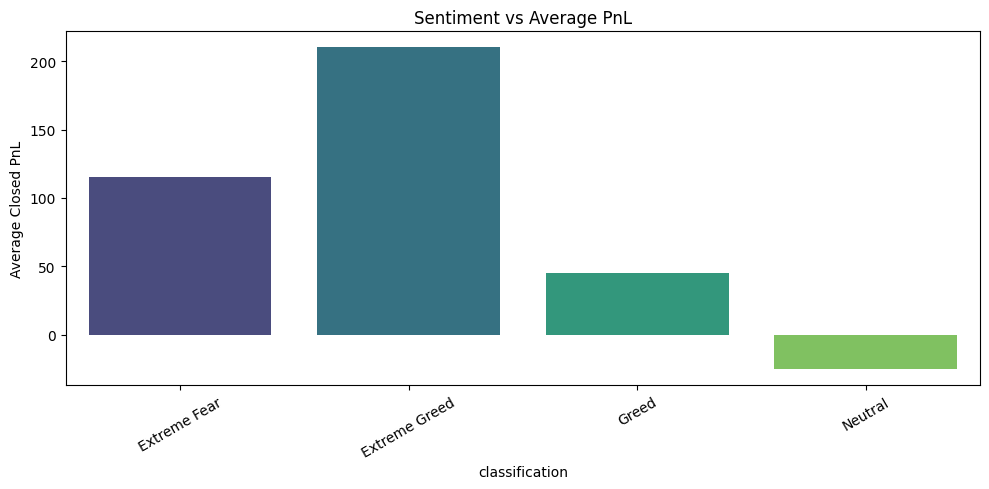

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19356\16645740.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_win_rate, x='classification', y='Win', palette='magma')


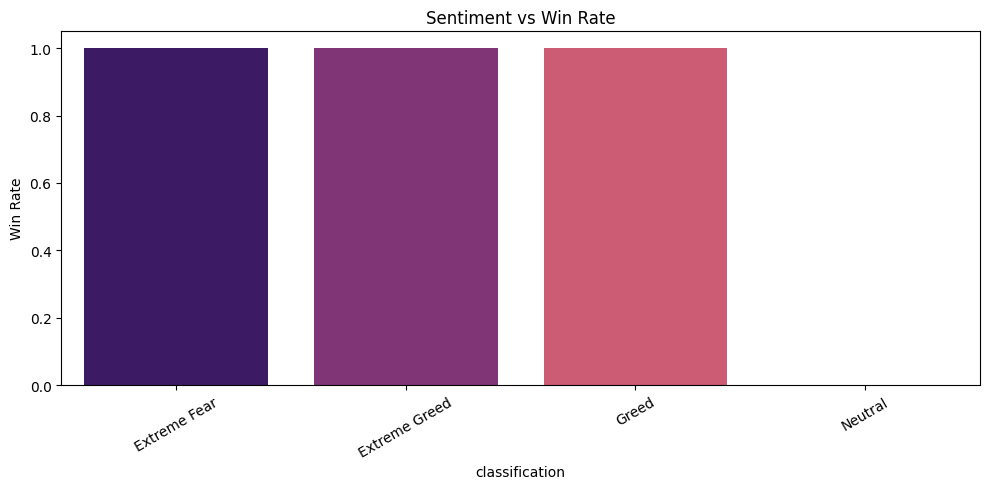

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19356\16645740.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_avg_size, x='classification', y='Size USD', palette='Blues')


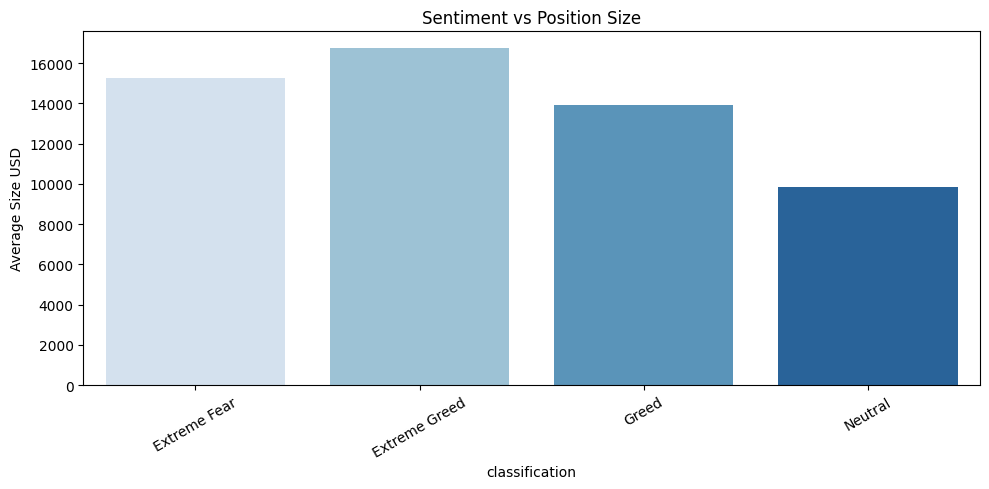

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19356\16645740.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_avg_fee, x='classification', y='Fee', palette='rocket')


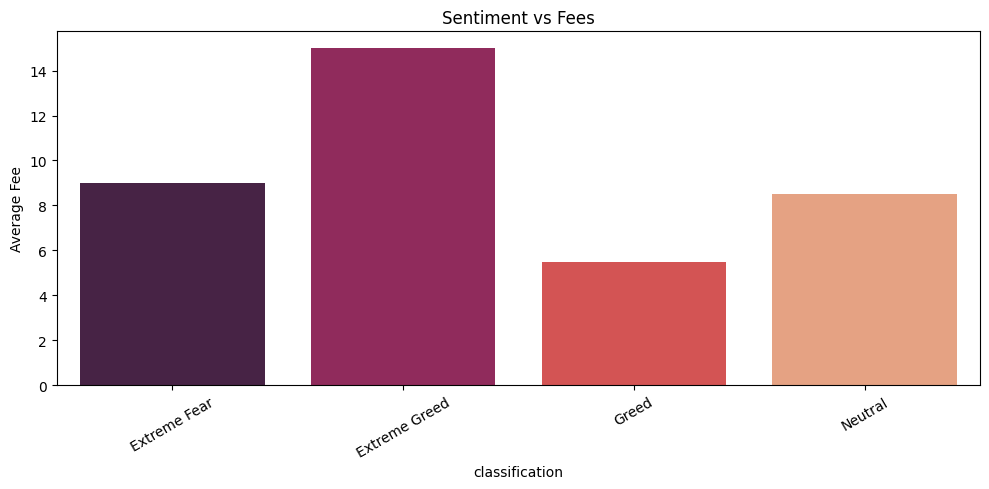

In [11]:
# Make the plotting cell self-contained and robust to reruns
if 'Win' not in merged.columns:
    merged['Win'] = merged['Closed PnL'] > 0

sentiment_avg_pnl = merged.groupby('classification', dropna=False)['Closed PnL'].mean().reset_index()
sentiment_win_rate = merged.groupby('classification', dropna=False)['Win'].mean().reset_index()
sentiment_avg_size = merged.groupby('classification', dropna=False)['Size USD'].mean().reset_index()
sentiment_avg_fee = merged.groupby('classification', dropna=False)['Fee'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_avg_pnl, x='classification', y='Closed PnL', palette='viridis')
plt.title('Sentiment vs Average PnL')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_win_rate, x='classification', y='Win', palette='magma')
plt.title('Sentiment vs Win Rate')
plt.ylabel('Win Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_avg_size, x='classification', y='Size USD', palette='Blues')
plt.title('Sentiment vs Position Size')
plt.ylabel('Average Size USD')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_avg_fee, x='classification', y='Fee', palette='rocket')
plt.title('Sentiment vs Fees')
plt.ylabel('Average Fee')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
